# Milestone 2 — what came back from the city-wide run

`measure_hexes.py` reduced eight years of Sentinel-2 to one small table: 2,868 H3 hexes x 8 years,
greenness and wetness per hex per year. This notebook looks at that table **before any
normalisation** — absolute values only, exactly as stored.

That restriction is the point. The next step differences every hex against the city-wide median for
its year, and a normalised map is much harder to sanity-check because the normalisation can hide
its own mistakes. Everything here is one step from the CSV.

Four questions, in order:

1. **Is the table sound?** — coverage, duplicates, pixel counts
2. **What does a year look like?** — the distribution across 2,868 hexes, and how it moves
3. **Where is the green?** — hexes on a map, 2019 and 2026
4. **What happens if you just subtract the endpoints?** — the trap the next step exists to avoid

Then one check on the `wet` column, which came along free and has not been looked at yet.

**No Earth Engine.** Unlike `m1_spot_check.ipynb` this runs entirely off local files and needs no
auth, so it will re-run in any future session. It reads `results/m2_hex_table.csv` (committed) plus
`data/hex_grid.geojson`, `data/study_boundary.geojson` and `data/osm_sites.geojson` — all three are
gitignored and regenerate from `build_grid.py` and `fetch_sites.py` in one call each.

In [1]:
import math
import os
from pathlib import Path

import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from shapely.geometry import Point

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO)

METRIC = "EPSG:32643"        # gotcha 4: anything in map units, never degrees
INK, MUTED = "#2b2b2b", "#8a8a8a"
LOSS, GAIN = "#8c2d04", "#1b7837"                       # the diverging poles, as in render_sites.py
VARTHUR_C, LALBAGH_C = "#7b3294", "#1b7837"             # two series, CVD-separated

CHANGE = LinearSegmentedColormap.from_list(
    "change", ["#8c2d04", "#fdd49e", "#f7f7f7", "#a6dba0", "#1b7837"])

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.edgecolor": MUTED, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.25, "grid.linewidth": 0.6,
})

table = pd.read_csv("results/m2_hex_table.csv")
grid = gpd.read_file("data/hex_grid.geojson")
boundary = gpd.read_file("data/study_boundary.geojson")
sites = gpd.read_file("data/osm_sites.geojson").set_index("site")
YEARS = sorted(table.year.unique())

print(f"{len(table):,} rows   {table.h3.nunique():,} hexes x {len(YEARS)} years "
      f"({YEARS[0]}-{YEARS[-1]})")
table.head()

22,944 rows   2,868 hexes x 8 years (2019-2026)


,h3,year,green,wet,n_pixels
0,886014402dfffff,2019,0.290053,-0.486036,7971
1,8860144041fffff,2019,0.255700,-0.456326,7972
2,8860144043fffff,2019,0.252198,-0.500435,7977
3,8860144045fffff,2019,0.279966,-0.519911,7972
4,8860144047fffff,2019,0.213142,-0.505851,7973


---
## 1 — Is the table sound?

Four things have to hold before any of it means anything, and each one fails loudly here rather
than quietly downstream — the same discipline `build_grid.py` uses with its three asserts.

The load-bearing one is the last. `n_pixels` is the data-quality column: a hex whose pixel count
collapses in one year has a cloud gap, and comparing that year to another compares **different
ground**. That is precisely the failure that made 2016 unusable at milestone 1 — its single scene
covered 2.8% of the Varthur polygon, so its greenness measured a different place, not the same
place badly.

In [2]:
assert len(table) == len(grid) * len(YEARS), "grid and table disagree on hex count"
assert not table.duplicated(["h3", "year"]).any(), "duplicate (hex, year) rows"
assert table[["green", "wet", "n_pixels"]].notna().all().all(), "nulls in measured columns"

per_hex = table.groupby("h3")["n_pixels"]
swing = per_hex.max() - per_hex.min()
assert (swing / per_hex.min()).max() < 0.05, "a hex changes size across years — cloud gap"

print("every (hex, year) present, no duplicates, no nulls")
print(f"pixels per hex           {table.n_pixels.min():,} - {table.n_pixels.max():,} "
      f"across hexes (median {int(table.n_pixels.median()):,})")
print(f"hexes whose count moves  {(swing > 0).sum()} of {table.h3.nunique():,}   "
      f"(largest swing across the 8 years: {swing.max()} pixels)")

every (hex, year) present, no duplicates, no nulls
pixels per hex           7,966 - 8,042 across hexes (median 8,004)
hexes whose count moves  0 of 2,868   (largest swing across the 8 years: 0 pixels)


The counts sit ~5% above the 7,580 a 0.758 km² hex implies at 10 m, which is projection difference
between EPSG:32643 and what Earth Engine reduces in — not an error. The counts vary between hexes
for the same reason.

What matters is the third line: **not one hex changes its pixel count across the eight years, by a
single pixel.** So there is no cloud gap anywhere in the table, and every year-to-year comparison
in it is the same ground measured twice. That is a stronger result than the ±5% tolerance the
script was written to allow.

---
## 2 — What a year looks like

One box per year, over all 2,868 hexes. The interesting thing is not any single year, it is that
**the whole distribution moves bodily** — median, quartiles and both tails together.

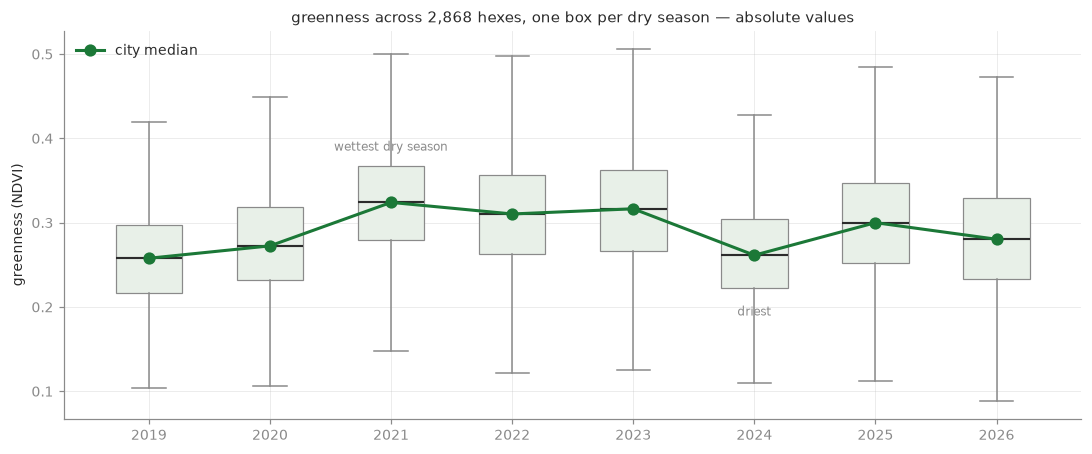

In [3]:
by_year = [table.loc[table.year == y, "green"].to_numpy() for y in YEARS]
med = table.groupby("year")["green"].median()

fig, ax = plt.subplots(figsize=(10, 4.2))
bp = ax.boxplot(by_year, positions=YEARS, widths=0.55, showfliers=False, patch_artist=True,
                medianprops={"color": INK, "linewidth": 1.4},
                whiskerprops={"color": MUTED}, capprops={"color": MUTED})
for patch in bp["boxes"]:
    patch.set(facecolor="#e8f0e8", edgecolor=MUTED, linewidth=0.8)
ax.plot(med.index, med.values, "o-", color=GAIN, linewidth=2, markersize=7,
        zorder=3, label="city median")

q = table.groupby("year")["green"].quantile([0.25, 0.75]).unstack()
for y, note, edge_q, dy in ((2021, "wettest dry season", 0.75, 10), (2024, "driest", 0.25, -18)):
    ax.annotate(note, (y, q.loc[y, edge_q]), textcoords="offset points", xytext=(0, dy),
                ha="center", fontsize=8, color=MUTED)

ax.set_xticks(YEARS)
ax.set_xlim(YEARS[0] - 0.7, YEARS[-1] + 0.7)
ax.set_ylabel("greenness (NDVI)")
ax.set_title("greenness across 2,868 hexes, one box per dry season — absolute values", fontsize=10)
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()

2021 sits 0.066 above 2019, and by 2024 the whole distribution is back within 0.004 of where it
started. Nothing about Bangalore's land cover moved that far in three years and then unmoved — this
is dry-season moisture and rainfall timing, which is gotcha 8 seen at city scale instead of at one
site.

Two consequences, and the second is the whole reason milestone 2 has a step 2:

- **An absolute per-year value cannot be read as change.** The year-to-year wobble is larger than
  anything eight years of real development would produce.
- **That green line is the quantity the next step subtracts.** Differencing each hex against the
  city median for its year removes exactly this common movement, leaving what is specific to the
  hex. Everything in this notebook is deliberately *before* that subtraction.

So: does the city get greener over 2019–2026 in absolute terms? The fit below answers it, and the
answer is that the question is not answerable from this data.

In [4]:
def fit(values):
    '''Least-squares slope per year, its standard error and t. Plain arithmetic, as in M1.'''
    n = len(values)
    xs = list(range(n))
    mx, my = sum(xs) / n, sum(values) / n
    sxx = sum((x - mx) ** 2 for x in xs)
    slope = sum((x - mx) * (v - my) for x, v in zip(xs, values)) / sxx
    icept = my - slope * mx
    resid = [v - (icept + slope * x) for x, v in zip(xs, values)]
    sd = math.sqrt(sum(r * r for r in resid) / (n - 2))
    se = sd / math.sqrt(sxx)
    return slope, se, slope / se, icept

city = table.groupby("year")["green"].mean()
slope, se, t, _ = fit(city.tolist())
span = len(YEARS) - 1

print(f"city mean greenness      {city.iloc[0]:.4f} ({YEARS[0]})  ->  {city.iloc[-1]:.4f} ({YEARS[-1]})")
print(f"endpoint difference      {city.iloc[-1] - city.iloc[0]:+.4f}")
print(f"fitted slope             {slope:+.5f} / yr   (se {se:.5f},  t = {t:.2f})")
print(f"fitted total, {len(YEARS)} seasons   {slope * span:+.4f}")
print(f"largest single-year jump {city.diff().abs().max():+.4f}")
print()
print(f"95% range on that total  "
      f"{(slope - 2.45 * se) * span:+.4f} to {(slope + 2.45 * se) * span:+.4f}")

city mean greenness      0.2617 (2019)  ->  0.2840 (2026)
endpoint difference      +0.0223
fitted slope             +0.00115 / yr   (se 0.00396,  t = 0.29)
fitted total, 8 seasons   +0.0081
largest single-year jump +0.0520

95% range on that total  -0.0599 to +0.0760


Three numbers to read together:

- The **endpoint difference (+0.022)** is nearly three times the **fitted total (+0.008)**.
  Picking which two years to subtract changes the answer by more than the answer is. That is why
  the project rule is: endpoints are fine for *rendering a picture*, any *quoted figure* comes from
  the slope.
- `t = 0.29`, far below the 2.45 that eight points need at 5%. The 95% range spans zero in both
  directions.
- The fitted total is **five times smaller than a single year's wobble.** Whatever the series is
  measuring, it is not a trend.

This re-derives, from the hex table and different geometry, the result already logged on
2026-09-11 (+0.00163/yr, t = 0.40). That figure was measured pixel-weighted over a 2,700 km² box;
this one is the unweighted mean of 2,868 hex means over 2,173 km², so the two are not expected to
match to the digit. They agree on the only thing that matters: **there is no readable city-wide
greenness trend**, and the project does not claim one.

---
## 3 — Where the green is

The map the table was built for. Same colour scale in both panels, so the two are comparable, and
limits are clipped to the 2nd–98th percentile so a handful of extreme hexes don't flatten
everything else into one shade.

Projected to EPSG:32643 for drawing (gotcha 4) — in raw degrees the hexes come out stretched,
because a degree of longitude at 13°N is shorter than a degree of latitude.

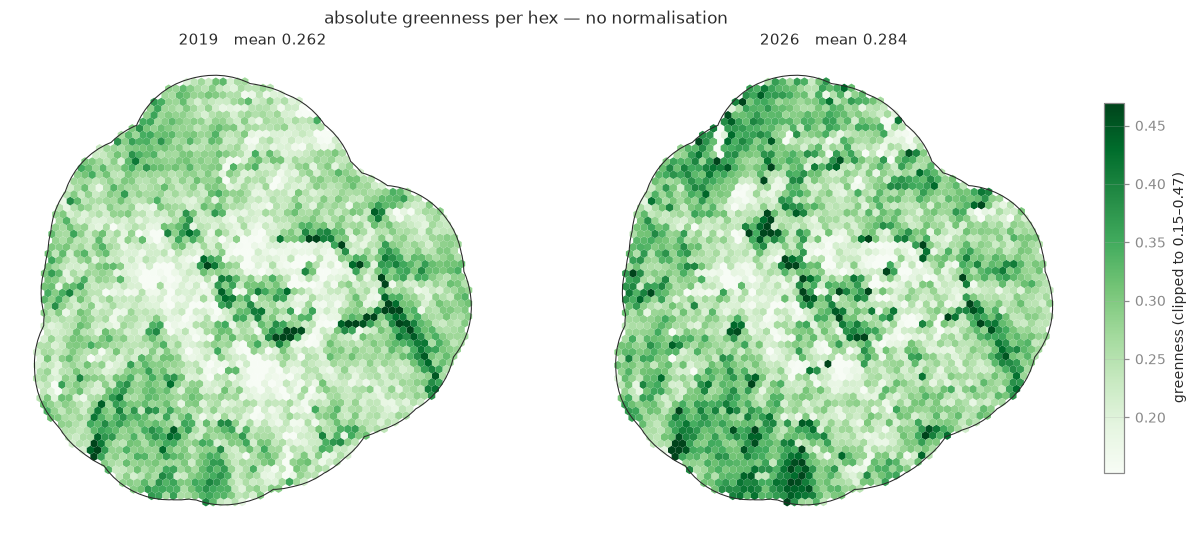

In [5]:
wide = table.pivot(index="h3", columns="year", values="green").add_prefix("g")
gm = grid.merge(wide, on="h3").to_crs(METRIC)
edge = boundary.to_crs(METRIC).boundary

lo, hi = table.green.quantile([0.02, 0.98])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.6))
for ax, year in zip(axes, (YEARS[0], YEARS[-1])):
    gm.plot(column=f"g{year}", cmap="Greens", vmin=lo, vmax=hi, ax=ax, linewidth=0)
    edge.plot(ax=ax, color=INK, linewidth=0.7)
    ax.set_title(f"{year}   mean {table.loc[table.year == year, 'green'].mean():.3f}", fontsize=10)
    ax.set_axis_off()

fig.subplots_adjust(right=0.9)
cax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
fig.colorbar(plt.cm.ScalarMappable(cmap="Greens",
                                   norm=plt.Normalize(vmin=lo, vmax=hi)), cax=cax,
             label=f"greenness (clipped to {lo:.2f}–{hi:.2f})")
fig.suptitle("absolute greenness per hex — no normalisation", fontsize=11, y=0.95)
plt.show()

The structure is the one Bangalore actually has: a pale, low core where the built-up city is, a
darker ring of peri-urban agriculture and plantation on the fringe, and the 10 km ring picking up
the countryside beyond. Nothing in either panel is surprising, which is the useful result — a
broken pipeline would not have produced a city-shaped city.

It also shows why gotcha 3 escalates at this scale: most of the darkest hexes are **fringe farmland,
not canopy**. NDVI cannot tell a mature tree from a standing crop, and the fringe is where both the
farmland and the development are.

---
## 4 — The trap: subtracting the endpoints

Take the 2026 panel, subtract the 2019 panel, and colour the difference. This is the obvious thing
to do and it is wrong, so it is worth seeing wrong.

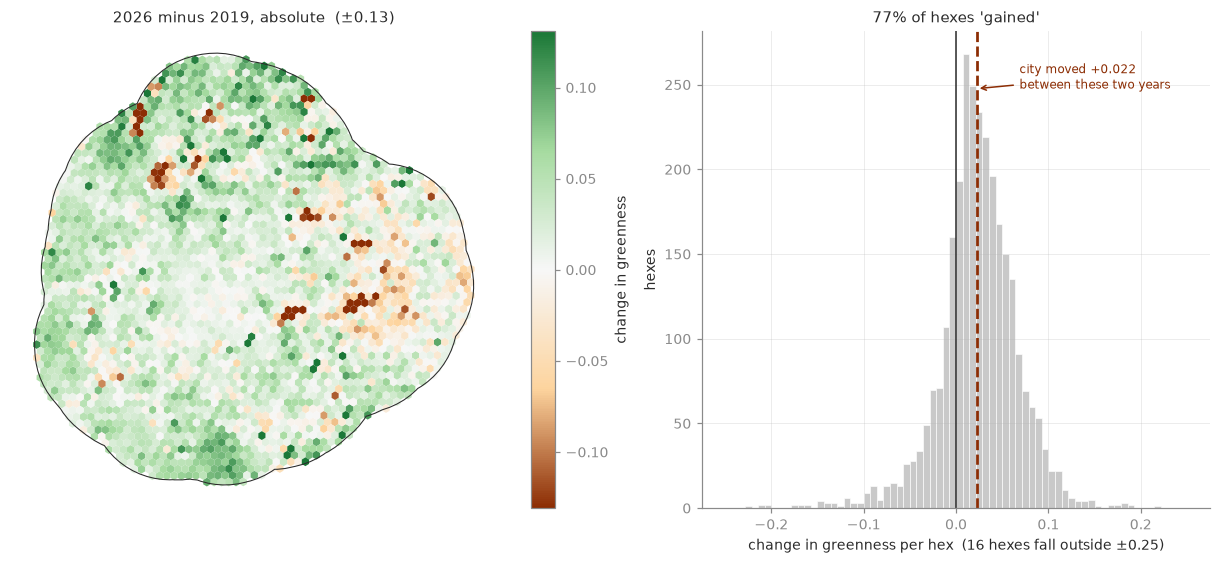

In [6]:
gm["delta"] = gm[f"g{YEARS[-1]}"] - gm[f"g{YEARS[0]}"]
city_shift = city.iloc[-1] - city.iloc[0]
lim = gm.delta.abs().quantile(0.98)

fig, (ax_map, ax_hist) = plt.subplots(
    1, 2, figsize=(12.5, 5.2), gridspec_kw={"width_ratios": [1.35, 1]})

gm.plot(column="delta", cmap=CHANGE, vmin=-lim, vmax=lim, ax=ax_map, linewidth=0)
edge.plot(ax=ax_map, color=INK, linewidth=0.7)
ax_map.set_title(f"{YEARS[-1]} minus {YEARS[0]}, absolute  (±{lim:.2f})", fontsize=10)
ax_map.set_axis_off()
fig.colorbar(plt.cm.ScalarMappable(cmap=CHANGE, norm=plt.Normalize(-lim, lim)),
             ax=ax_map, fraction=0.035, label="change in greenness")

HIST_LIM = 0.25
outside = (gm.delta.abs() > HIST_LIM).sum()
ax_hist.hist(gm.delta, bins=70, range=(-HIST_LIM, HIST_LIM),
             color="#c9c9c9", edgecolor="white", linewidth=0.4)
ax_hist.axvline(0, color=INK, linewidth=1)
ax_hist.axvline(city_shift, color=LOSS, linewidth=1.8, linestyle="--")
ax_hist.annotate(f"city moved {city_shift:+.3f}\nbetween these two years",
                 (city_shift, ax_hist.get_ylim()[1] * 0.88), xytext=(28, 0),
                 textcoords="offset points", fontsize=8, color=LOSS,
                 arrowprops={"arrowstyle": "->", "color": LOSS, "linewidth": 1})
ax_hist.set_xlabel(f"change in greenness per hex  ({outside} hexes fall outside ±{HIST_LIM})")
ax_hist.set_ylabel("hexes")
ax_hist.set_title(f"{(gm.delta > 0).mean() * 100:.0f}% of hexes 'gained'", fontsize=10)
plt.tight_layout()

Most of the map is green and most of the histogram sits right of zero — and section 2 already
established that **+0.022 of that is the two years' weather**, not anything on the ground. A reader
shown this map would conclude Bangalore greened between 2019 and 2026. The data does not say that.

The fix is not a different pair of years; every pair carries its own weather. The fix is to take
the offset out, hex by hex, against the city median for the same year — which is step 2, and is
deliberately not in this notebook.

Worth keeping separate, because they pull in opposite directions: the *shape* of this map is
informative (the hexes at the extremes really did change relative to their neighbours), while its
*level* is not. Normalising fixes the level and leaves the shape alone.

---
## 5 — Does the grid agree with milestone 1?

Milestone 1 measured two places by hand, with traced OpenStreetMap outlines and no hex grid
anywhere. Both fall inside this boundary, so the hex table can be asked the same question through
completely different machinery.

Hex membership is by **centre**, in lat/lng, exactly as `build_grid.py` decided it — using
`h3.cell_to_latlng` rather than a reprojected polygon centroid, so this reproduces the grid's own
convention instead of approximating it.

One trap, already paid for on 2026-09-11: **a single hex is not a site.** Varthur's centroid hex
sits mostly on the lake and Lalbagh (1.4 x 1.1 km) is smaller than a 0.758 km² hex, so its hex is
mostly the surrounding city. Aggregate the hexes covering a region; never pick the centroid's.

In [7]:
centres = gpd.GeoDataFrame(
    {"h3": grid.h3},
    geometry=[Point(lng, lat) for lat, lng in (h3.cell_to_latlng(c) for c in grid.h3)],
    crs="EPSG:4326",
)

members = {name: set(centres.loc[centres.within(sites.loc[name, "geometry"]), "h3"])
           for name in ("varthur_area", "lalbagh")}

lake_poly = gpd.GeoSeries([sites.loc["varthur_lake", "geometry"]], crs="EPSG:4326").to_crs(METRIC).iloc[0]
in_metric = grid.set_index("h3").to_crs(METRIC).geometry
share = in_metric.loc[sorted(members["varthur_area"])].intersection(lake_poly).area / lake_poly.area
LAKE_HEX = share.idxmax()
members["varthur_no_lake"] = members["varthur_area"] - {LAKE_HEX}

for name in ("varthur_area", "varthur_no_lake", "lalbagh"):
    print(f"{name:16s} {len(members[name]):2d} hexes")
print(f"\none of Varthur's hexes holds {share.max() * 100:.0f}% of the lake itself: {LAKE_HEX}\n")

series = pd.DataFrame({
    name: table[table.h3.isin(cells)].groupby("year")["green"].mean()
    for name, cells in members.items()
}).assign(city=table.groupby("year")["green"].mean())

for name in ("varthur_area", "varthur_no_lake", "lalbagh"):
    slope, se, t, _ = fit((series[name] - series.city).tolist())
    print(f"{name:16s} vs the city mean:  {slope:+.4f}/yr   t = {t:+.2f}")

varthur_area     12 hexes
varthur_no_lake  11 hexes
lalbagh           2 hexes

one of Varthur's hexes holds 40% of the lake itself: 88618920e1fffff

varthur_area     vs the city mean:  -0.0138/yr   t = -2.62
varthur_no_lake  vs the city mean:  -0.0095/yr   t = -3.73
lalbagh          vs the city mean:  +0.0007/yr   t = +0.25


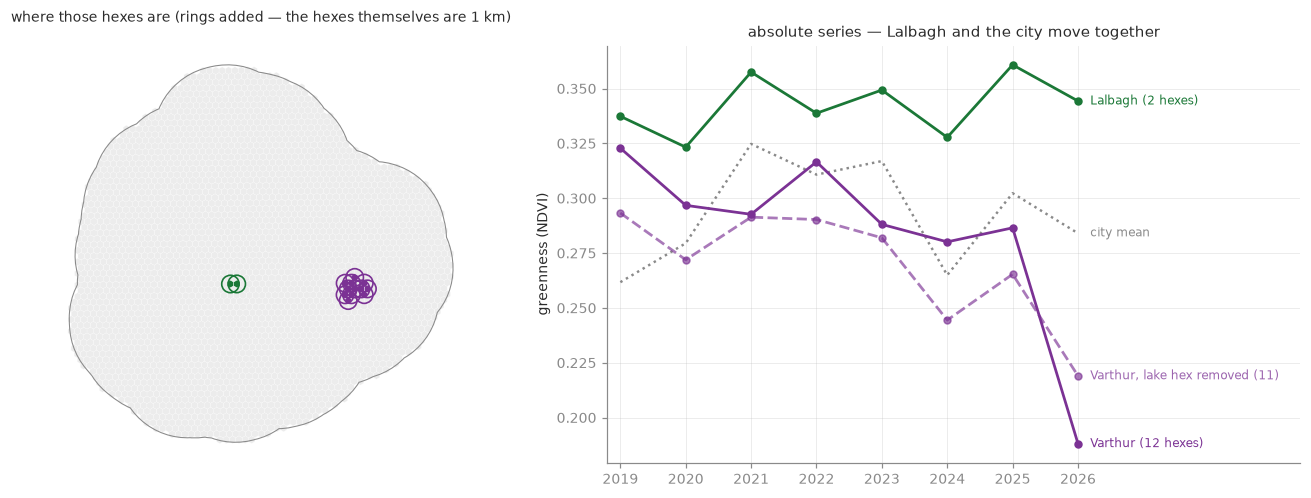

In [8]:
fig, (ax_map, ax_ser) = plt.subplots(
    1, 2, figsize=(12.5, 4.6), gridspec_kw={"width_ratios": [1, 1.25]})

gm.plot(ax=ax_map, color="#ececec", edgecolor="white", linewidth=0.15)
edge.plot(ax=ax_map, color=MUTED, linewidth=0.7)
for name, colour in (("varthur_area", VARTHUR_C), ("lalbagh", LALBAGH_C)):
    picked = gm[gm.h3.isin(members[name])]
    picked.plot(ax=ax_map, color=colour, edgecolor="white", linewidth=0.3)
    ax_map.scatter(*zip(*((g.x, g.y) for g in picked.geometry.centroid)),
                   s=130, facecolor="none", edgecolor=colour, linewidth=1.1)
ax_map.set_title("where those hexes are (rings added — the hexes themselves are 1 km)", fontsize=9)
ax_map.set_axis_off()

ax_ser.plot(series.index, series.city, ":", color=MUTED, linewidth=1.6)
ax_ser.annotate("city mean", (YEARS[-1], series.city.iloc[-1]), xytext=(8, 0),
                textcoords="offset points", fontsize=8, color=MUTED, va="center")
lines = (("lalbagh", LALBAGH_C, "-", "Lalbagh (2 hexes)"),
         ("varthur_area", VARTHUR_C, "-", "Varthur (12 hexes)"),
         ("varthur_no_lake", VARTHUR_C, "--", "Varthur, lake hex removed (11)"))
for name, colour, style, label in lines:
    ax_ser.plot(series.index, series[name], "o", linestyle=style, color=colour,
                linewidth=1.8, markersize=4.5, alpha=1 if style == "-" else 0.65)
    ax_ser.annotate(label, (YEARS[-1], series[name].iloc[-1]), xytext=(8, 0),
                    textcoords="offset points", fontsize=8, color=colour, va="center",
                    alpha=1 if style == "-" else 0.75)

ax_ser.set_xticks(YEARS)
ax_ser.set_xlim(YEARS[0] - 0.2, YEARS[-1] + 3.4)
ax_ser.set_ylabel("greenness (NDVI)")
ax_ser.set_title("absolute series — Lalbagh and the city move together", fontsize=10)
plt.tight_layout()

Lalbagh and the city mean rise into 2021 and dip in 2024 together — the shared movement section 2
measured, and the thing step 2 removes. Lalbagh's two hexes sit above the city and flat, as its
role as M1's control requires, though they read **below** M1's 0.44–0.50 for the garden itself:
at 0.758 km² per hex those two cells are mostly the city around Lalbagh, not Lalbagh.

Varthur drifts downward **against** the city, which is the result milestone 1 reached by an
entirely different route — traced OSM polygons, differenced against Lalbagh rather than the city,
at −0.0119/yr with t = −3.18. That remains the only time M2's machinery has been confirmed by
something outside itself.

But the two Varthur lines are worth separating, because **one of those 12 hexes holds 40% of
Varthur lake**, and it is what produces the cliff in 2026:

| | slope vs city | t |
|---|---|---|
| all 12 hexes | −0.0138/yr | −2.62 |
| 11 hexes, lake hex removed | −0.0095/yr | **−3.73** |
| M1, traced polygon with the lake punched out | −0.0119/yr | −3.18 |

Removing it makes the decline *smaller* and the evidence *stronger* — a shallower slope against much
less scatter. And it is the fairer comparison, because M1's `varthur_built` had the lake subtracted
out by construction. So the logged 12-hex figure understates the agreement between M1 and M2 rather
than overstating it.

Which leaves the question of what that one hex is doing — and the answer is in the column that
has not been looked at yet.

---
## 6 — The `wet` column, looked at once

MNDWI came back in the same pass as greenness, so milestone 3's blue layer needs no re-run. It has
not been examined at city scale yet. One falsifiable question, fixed before looking:

> **The hexes containing a known lake should rank in the top 10% by wetness.**

Only two lakes are pinned by OSM id in this project (gotcha 7 — recalled coordinates are not
evidence), so that is a two-case test, not a survey. It is still enough to fail.

In [9]:
TOP_FRACTION = 0.10

wet26 = table[table.year == YEARS[-1]].set_index("h3")["wet"]
rank = wet26.rank(pct=True)

lake_grid = grid.to_crs(METRIC)
lake_hex = {}
for lake in ("varthur_lake", "kaikondrahalli_lake"):
    poly = gpd.GeoSeries([sites.loc[lake, "geometry"]], crs="EPSG:4326").to_crs(METRIC).iloc[0]
    hit = lake_grid[lake_grid.intersects(poly)]
    share = hit.geometry.intersection(poly).area / poly.area
    lake_hex[lake] = hit.loc[share.idxmax(), "h3"]
    cell = lake_hex[lake]
    print(f"{lake:22s} spans {len(hit)} hexes; largest holds {share.max() * 100:4.1f}% of the lake")
    print(f"{'':22s} that hex: wet {wet26[cell]:+.3f}, "
          f"percentile {rank[cell] * 100:4.1f}  "
          f"-> {'PASS' if rank[cell] >= 1 - TOP_FRACTION else 'FAIL'}")

print(f"\nof {len(wet26):,} hexes, {(wet26 > 0).sum()} read positive and "
      f"{(wet26 > 0.3).sum()} clear +0.3 (open water)")

varthur_lake           spans 9 hexes; largest holds 40.1% of the lake
                       that hex: wet +0.383, percentile 99.9  -> PASS
kaikondrahalli_lake    spans 3 hexes; largest holds 60.4% of the lake
                       that hex: wet -0.277, percentile 95.6  -> PASS

of 2,868 hexes, 5 read positive and 3 clear +0.3 (open water)


Both pass, but they pass in completely different registers — +0.383 against −0.277 — and the first
one is not a lake-detection result at all. It is the thing the no-masking decision was written
about, caught in the act.

### The Varthur hex flips in 2026

Milestone 1 established that Varthur lake was carrying a dense floating mat that photosynthesises,
reading **0.82 greenness** — higher than Lalbagh ever reaches — and that by 2026 the same lake
rendered brown. The hex containing it records both halves of that.

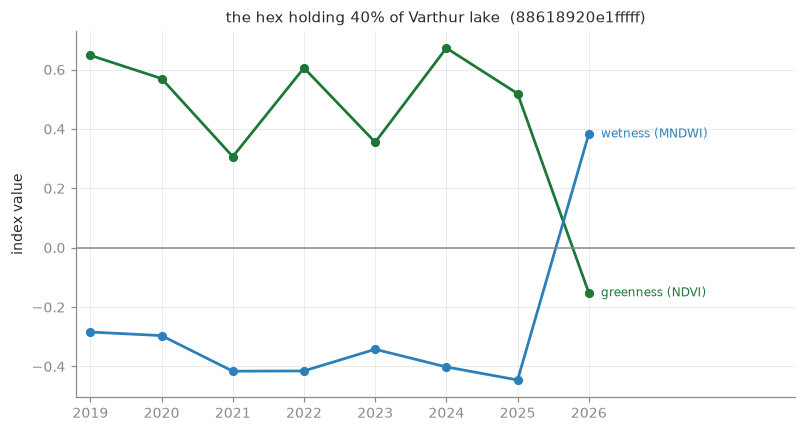

greenness +0.648 -> -0.152   (-0.800)
wetness   -0.284 -> +0.383

rank by absolute 2019->2026 greenness change: 2 of 2,868 largest losses in the grid


In [10]:
cell = lake_hex["varthur_lake"]
lake_series = table[table.h3 == cell].set_index("year")[["green", "wet"]]

delta = (wide[f"g{YEARS[-1]}"] - wide[f"g{YEARS[0]}"]).sort_values()
place = list(delta.index).index(cell) + 1

fig, ax = plt.subplots(figsize=(7.4, 4))
for col, colour, label in (("green", GAIN, "greenness (NDVI)"), ("wet", "#2c7fb8", "wetness (MNDWI)")):
    ax.plot(lake_series.index, lake_series[col], "o-", color=colour, linewidth=1.8, markersize=5)
    ax.annotate(label, (YEARS[-1], lake_series[col].iloc[-1]), xytext=(8, 0),
                textcoords="offset points", fontsize=8, color=colour, va="center")
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_xticks(YEARS)
ax.set_xlim(YEARS[0] - 0.2, YEARS[-1] + 2.9)
ax.set_ylabel("index value")
ax.set_title(f"the hex holding 40% of Varthur lake  ({cell})", fontsize=10)
plt.tight_layout()
plt.show()

print(f"greenness {lake_series.green.iloc[0]:+.3f} -> {lake_series.green.iloc[-1]:+.3f}   "
      f"({lake_series.green.iloc[-1] - lake_series.green.iloc[0]:+.3f})")
print(f"wetness   {lake_series.wet.iloc[0]:+.3f} -> {lake_series.wet.iloc[-1]:+.3f}")
print(f"\nrank by absolute {YEARS[0]}->{YEARS[-1]} greenness change: "
      f"{place} of {len(delta):,} largest losses in the grid")

The two lines cross in 2026 and nothing gradual happens before it. Greenness falls off a cliff into
negative territory and wetness jumps above zero in the same step: the mat went, open water appeared.

This hex is the **second** largest greenness loss in the whole grid, and it is not canopy loss. It
is a lake becoming visible as a lake. On an unexamined ranking it would be near the headline, and
the headline would be backwards — a clearing reported as destruction.

Which raises the obvious question about the hexes around it in that ranking.

### The top of the loss ranking, checked

Same signature to look for: greenness collapsing while wetness rises in the same year. The city
median wetness is −0.454, so anything approaching zero is unusual.

In [11]:
wet_wide = table.pivot(index="h3", columns="year", values="wet")
first, last = YEARS[0], YEARS[-1]

top = delta.head(20).index
losses = pd.DataFrame({
    "green_change": delta[top],
    "wet_change": (wet_wide[last] - wet_wide[first])[top],
    "wet_2026": wet_wide.loc[top, last],
    "worst_year": wide.loc[top].rename(columns=lambda c: int(c[1:])).diff(axis=1).idxmin(axis=1),
})
losses["lat"], losses["lng"] = zip(*(h3.cell_to_latlng(c) for c in top))

print(losses.head(6).round(3).to_string())
print(f"\nof the 20 largest losses, {(losses.wet_2026 > -0.2).sum()} end up wetter than -0.2 "
      f"(city median {wet_wide[last].median():.3f})")
print(f"and {(losses.wet_change > 0).sum()} of 20 got wetter at all over the run  "
      f"<- section 7: this one is an artefact, not a finding")

                 green_change  wet_change  wet_2026  worst_year     lat     lng
h3                                                                             
8860169481fffff        -0.871       1.009     0.515        2023  13.151  77.488
88618920e1fffff        -0.800       0.667     0.383        2026  12.948  77.742
8860169485fffff        -0.612       0.700     0.151        2023  13.158  77.492
8861892c69fffff        -0.421       0.433    -0.002        2026  13.046  77.688
8861892509fffff        -0.373       0.180    -0.069        2021  12.933  77.665
88618920e3fffff        -0.327       0.264    -0.163        2021  12.948  77.733

of the 20 largest losses, 10 end up wetter than -0.2 (city median -0.454)
and 18 of 20 got wetter at all over the run  <- section 7: this one is an artefact, not a finding


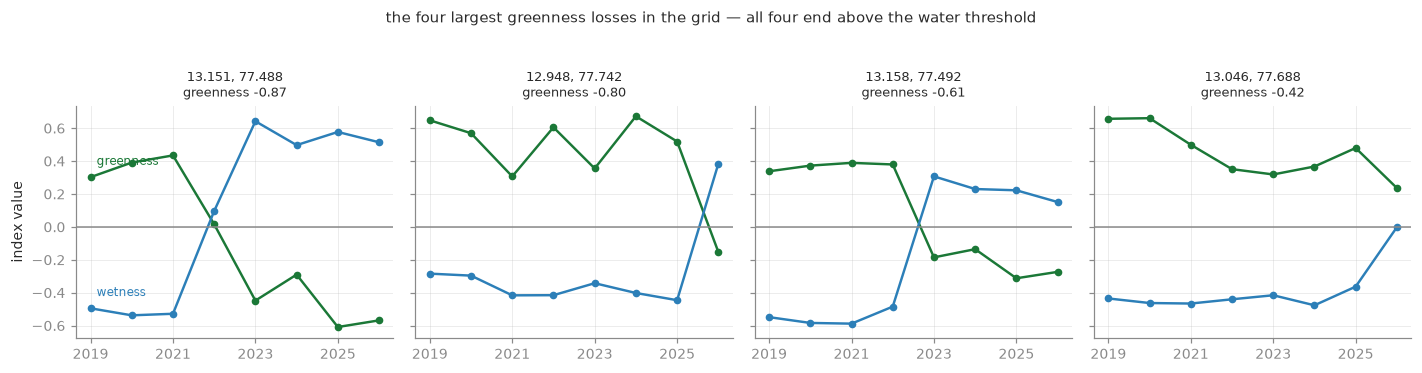

In [12]:
show = list(top[:4])
fig, axes = plt.subplots(1, len(show), figsize=(13, 3.2), sharey=True)
for ax, cell in zip(axes, show):
    row = table[table.h3 == cell].set_index("year")
    ax.plot(row.index, row.green, "o-", color=GAIN, linewidth=1.6, markersize=4)
    ax.plot(row.index, row.wet, "o-", color="#2c7fb8", linewidth=1.6, markersize=4)
    ax.axhline(0, color=MUTED, linewidth=1)
    ax.set_title(f"{losses.loc[cell, 'lat']:.3f}, {losses.loc[cell, 'lng']:.3f}\n"
                 f"greenness {losses.loc[cell, 'green_change']:+.2f}", fontsize=8.5)
    ax.set_xticks(YEARS[::2])
axes[0].set_ylabel("index value")
first_row = table[table.h3 == show[0]].set_index("year")
axes[0].annotate("greenness", (YEARS[0], first_row.green.iloc[0]), xytext=(4, 8),
                 textcoords="offset points", fontsize=8, color=GAIN)
axes[0].annotate("wetness", (YEARS[0], first_row.wet.iloc[0]), xytext=(4, 8),
                 textcoords="offset points", fontsize=8, color="#2c7fb8")
fig.suptitle("the four largest greenness losses in the grid — all four end above the water threshold",
             fontsize=10, y=1.04)
plt.tight_layout()
plt.show()

**Half of the twenty largest losses end up wetter than −0.2, against a city median of −0.454.** The
first three plotted above share one shape: a step, not a slope, with greenness and wetness swapping
sides in a single year — 2023 for the two neighbouring hexes in the north-west, 2026 for Varthur.
The fourth is a slower decline whose wetness still climbs from −0.44 to 0.

Two of those four sit side by side at 13.151 and 13.158, so they are one event spanning two hexes,
not two events.

A second statistic was originally read alongside that one — *18 of the 20 got wetter over the run at
all* — and **section 7 retires it.** Greenness change and wetness change correlate at −0.69 across
hexes, so selecting the largest losses selects hexes that got wetter almost by construction; the
correlation predicts about 20 of 20 and 18 is, if anything, slightly under. The conclusion is
unaffected and the other statistic survives a proper null, but the supporting evidence is one
number, not two.

**Their identities are not established and should not be guessed** — gotcha 7 exists because a
plausible-looking coordinate produced plausible-looking numbers once before. What is established is
the signature, and that it dominates the top of the ranking.

The consequence for step 2a is concrete rather than theoretical: an absolute top-N loss list is not
a canopy-loss list, it is a water-arrival list wearing one. The no-masking decision of 2026-09-11
accepted exactly this exposure and specified the mitigation as *eyeball the top-N against imagery
before promoting any of them* — that mitigation now has confirmed instances to catch rather than
hypothetical ones, and it was reached before the ranking existed rather than after, which is what
the mitigation asked for. Section 7 takes it further than an eyeball.

---

The city-wide wetness picture, for completeness:

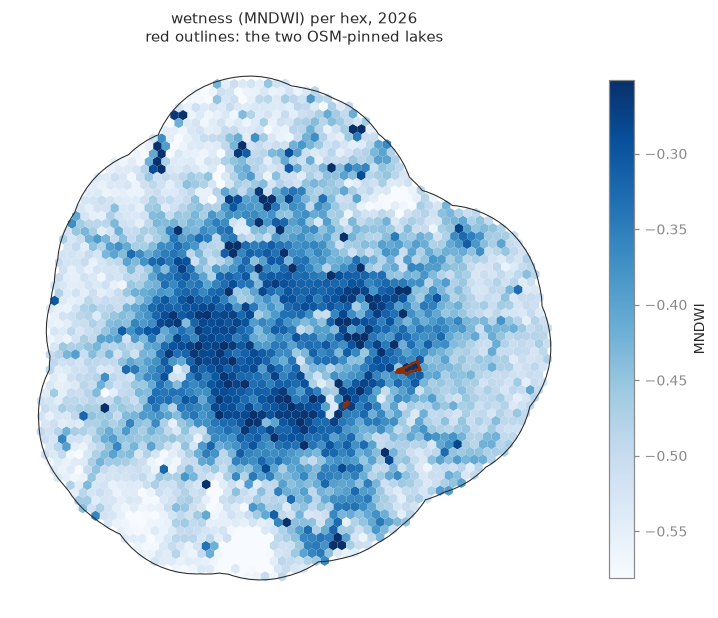

correlation between greenness and wetness across hexes, 2026: -0.648
over all 8 years: -0.598


In [13]:
gm["wet"] = gm.h3.map(wet26)
wlo, whi = wet26.quantile([0.02, 0.98])

fig, ax = plt.subplots(figsize=(6.6, 6))
gm.plot(column="wet", cmap="Blues", vmin=wlo, vmax=whi, ax=ax, linewidth=0)
edge.plot(ax=ax, color=INK, linewidth=0.7)
for lake, colour in (("varthur_lake", LOSS), ("kaikondrahalli_lake", LOSS)):
    gpd.GeoSeries([sites.loc[lake, "geometry"]], crs="EPSG:4326").to_crs(METRIC).boundary.plot(
        ax=ax, color=colour, linewidth=1.6)
ax.set_title(f"wetness (MNDWI) per hex, {YEARS[-1]}\nred outlines: the two OSM-pinned lakes",
             fontsize=10)
ax.set_axis_off()
fig.colorbar(plt.cm.ScalarMappable(cmap="Blues", norm=plt.Normalize(wlo, whi)),
             ax=ax, fraction=0.04, label="MNDWI")
plt.tight_layout()
plt.show()

same_year = table[table.year == YEARS[-1]]
print(f"correlation between greenness and wetness across hexes, {YEARS[-1]}: "
      f"{same_year.green.corr(same_year.wet):+.3f}")
print(f"over all {len(YEARS)} years: {table.green.corr(table.wet):+.3f}")

### Reading the map — and it is not what it looks like

The obvious reading is wrong, and the correlation printed under it gives the game away: across
hexes, wetness and greenness correlate at **−0.65**. The dark band through the middle of that map
is the built-up core, and it is dark because it is *not vegetated*, not because it is wet. Dry
vegetation reflects shortwave infrared strongly, so MNDWI slides upward wherever vegetation thins —
which at a 0.758 km² hex mean is most of what the index ends up measuring.

**Only 5 hexes out of 2,868 read positive at all**; everything else sits between −0.63 and 0. A
Bangalore lake is far smaller than a hex, so a hex mean dilutes open water into whatever surrounds
it, and only a lake occupying a large share of one cell — Varthur's 40% — pushes it over. Above
that threshold the index does mean water: the top of the ranking is real lakes, not just bare
ground.

So `wet` is doing two different jobs at two ends of its range, and only one of them is the job it
was chosen for. Milestone 3 will need the water test applied **per pixel and then counted**, rather
than the pixels averaged and the average tested. That is the same average-then-threshold versus
threshold-then-average question milestone 1 settled for greenness, arriving in a place where the
two do **not** commute. Logged, not solved — and it does not block the greenness work, which is
what M2 is for.

---
## 7 — Excluding the water

Section 6 established that `wet` only means *water* at the top of its range, and the ranking check
above established that water dominates the top of the loss list. This section turns that from a
warning into a filter: a fixed set of hexes, decided before step 2a ranks anything, and written out
so the rule lives in one place instead of two.

First, both halves of the ranking evidence get a null that knows what section 6 found — that
low-green hexes read wet for reasons that have nothing to do with water.

In [14]:
T = -0.2                           # section 6: above this, `wet` does mean water
first, last = YEARS[0], YEARS[-1]
dwet = wet_wide[last] - wet_wide[first]
loss20, gain20 = delta.head(20).index, delta.tail(20).index

r = delta.corr(dwet)
z = (delta[loss20].mean() - delta.mean()) / delta.std()
print("CLAIM 1 — 'of the 20 largest losses, 18 got wetter over the run'")
print(f"  r(greenness change, wetness change) across hexes = {r:+.3f}")
print(f"  the 20 largest losses sit at z = {z:+.2f} on greenness change, so that")
print(f"  correlation alone predicts E[z of wetness change] = {r * z:+.2f} — essentially all 20.")
print(f"  observed {(dwet[loss20] > 0).sum()} of 20, i.e. slightly UNDER what the correlation implies.")
print("  -> not evidence of water. Retired.")

g_last = wide[f"g{last}"]
bins = pd.qcut(g_last, 50, labels=False, duplicates="drop")
rate = (wet_wide[last] > T).groupby(bins).mean()
expected = bins[loss20].map(rate).sum()
observed = (wet_wide.loc[loss20, last] > T).sum()
naive = (wet_wide[last] > T).mean()

print(f"\nCLAIM 2 — 'of the 20 largest losses, {observed} end wetter than {T}'")
print(f"  naive base rate           {naive * 100:5.1f}%  ->  {naive * 20:.2f} of 20 expected")
print(f"  matched on {last} greenness           ->  {expected:.2f} of 20 expected")
print(f"  observed {observed} of 20  ->  {observed / expected:.1f}x over the null that already knows"
      " low-green hexes read wet")
print("  -> survives. This is the real signal, and it is the ABSOLUTE level, not the change.")

print(f"\nMIRROR CASE — the 20 largest GAINS")
print(f"  started wetter than {T} (open water in {first}): "
      f"{(wet_wide.loc[gain20, first] > T).sum()} of 20")
print(f"  ended   wetter than {T}:                       "
      f"{(wet_wide.loc[gain20, last] > T).sum()} of 20")

CLAIM 1 — 'of the 20 largest losses, 18 got wetter over the run'
  r(greenness change, wetness change) across hexes = -0.691
  the 20 largest losses sit at z = -6.35 on greenness change, so that
  correlation alone predicts E[z of wetness change] = +4.39 — essentially all 20.
  observed 18 of 20, i.e. slightly UNDER what the correlation implies.
  -> not evidence of water. Retired.

CLAIM 2 — 'of the 20 largest losses, 10 end wetter than -0.2'
  naive base rate             1.2%  ->  0.23 of 20 expected
  matched on 2026 greenness           ->  2.14 of 20 expected
  observed 10 of 20  ->  4.7x over the null that already knows low-green hexes read wet
  -> survives. This is the real signal, and it is the ABSOLUTE level, not the change.

MIRROR CASE — the 20 largest GAINS
  started wetter than -0.2 (open water in 2019): 7 of 20
  ended   wetter than -0.2:                       4 of 20


The mirror case is why a guard on the final year alone would not have been enough. Hyacinth is
invisible to MNDWI — 2026-09-11 measured Varthur at −0.33 to −0.43 through every weed-mat year — so
open water in 2019 that goes under a mat by 2026 reads as greenness climbing from nothing to dense
canopy, with the wetness evidence sitting in the *first* year and gone by the last. That is a
fabricated restoration, and the gain direction is the one M1 closed by decision on the promise that
this ranking would surface a real one if it existed.

So the test has to look at every year, not at one. Three ways to do that:

In [15]:
HEX_KM2 = grid.to_crs(METRIC).area.mean() / 1e6
n_wet = (wet_wide > T).sum(axis=1)
endpoint = (wet_wide[first] > T) | (wet_wide[last] > T)

slopes = wide.apply(lambda row: fit(row.tolist())[0], axis=1).sort_values()
sl_loss, sl_gain = slopes.head(20).index, slopes.tail(20).index

rules = {
    "A   wet in >=1 year (ever wet)": n_wet >= 1,
    "B   wet in >=2 of 8 years": n_wet >= 2,
    "C   wet in >=2 years, OR in an endpoint year": (n_wet >= 2) | endpoint,
}
print(f"{'rule':48s}{'hexes':>6}{'km2':>6}{'% area':>8}"
      f"{'endpoint top40':>16}{'slope top40':>13}")
for name, mask in rules.items():
    ep = mask.reindex(loss20).sum() + mask.reindex(gain20).sum()
    sl = mask.reindex(sl_loss).sum() + mask.reindex(sl_gain).sum()
    print(f"{name:48s}{mask.sum():6d}{mask.sum() * HEX_KM2:6.0f}"
          f"{mask.mean() * 100:7.1f}%{ep:16d}{sl:13d}")

print(f"\nthe {(n_wet == 1).sum()} hexes wet in exactly one year, by which year that is:")
print((wet_wide[n_wet == 1] > T).sum().loc[lambda s: s > 0].to_string())
print(f"\nof the single-year hexes that reach the endpoint top-20 loss list, "
      f"{((n_wet == 1) & (wet_wide[last] > T)).reindex(loss20).sum()} fire in {last}")

rule                                             hexes   km2  % area  endpoint top40  slope top40
A   wet in >=1 year (ever wet)                      56    42    2.0%              18           13
B   wet in >=2 of 8 years                           42    32    1.5%              14           10
C   wet in >=2 years, OR in an endpoint year        50    38    1.7%              18           13

the 14 hexes wet in exactly one year, by which year that is:
year
2019    1
2020    1
2023    4
2025    1
2026    7

of the single-year hexes that reach the endpoint top-20 loss list, 3 fire in 2026


Rule B is the intuitive one — wet once in eight years is a blip, not a lake — and it is right about
the middle of the run. It is blind at the edges. Half the single-year hexes fire in 2026, and every
single-year hex that reaches the top of the loss list is one of them: a lake flipping to open water
in the final season, which produces the largest endpoint collapse available and is the exact Varthur
shape from section 6. A "wet twice" test cannot see it, because 2026 has no 2027 to corroborate it
and 2019 has no 2018.

**Rule C: a hex is water if it reads wet in two or more years, or in either endpoint year.**

The endpoint clause is justified by that asymmetry, not by its catch rate — the catch rate against
the endpoint ranking is partly circular, since the clause and the ranking are keyed on the same two
years. The slope column beside it is the honest check: a ranking that does not privilege 2019 or
2026 at all, scored by the same three rules.

In [16]:
excluded = rules["C   wet in >=2 years, OR in an endpoint year"]
ids = n_wet.index[excluded]

water = pd.DataFrame({
    "n_years_wet": n_wet[ids],
    f"wet_{first}": wet_wide.loc[ids, first].round(4),
    f"wet_{last}": wet_wide.loc[ids, last].round(4),
    "peak_wet": wet_wide.loc[ids].max(axis=1).round(4),
})
recurrent, ends = n_wet[ids] >= 2, endpoint[ids]
water["caught_by"] = ["both" if b else "recurrent" if a else "endpoint"
                      for a, b in zip(recurrent, recurrent & ends)]
water.sort_values("peak_wet", ascending=False).to_csv("results/m2_water_hexes.csv")

kept = table[~table.h3.isin(ids)]
print(f"excluded {len(ids)} hexes, {len(ids) * HEX_KM2:.0f} km2, "
      f"{excluded.mean() * 100:.1f}% of the grid   -> results/m2_water_hexes.csv")
print(water.caught_by.value_counts().to_string())
print(f"\nstudy size   {table.h3.nunique():,} -> {kept.h3.nunique():,} hexes"
      f"   |   {len(table):,} -> {len(kept):,} rows"
      f"   |   {table.h3.nunique() * HEX_KM2:,.0f} -> {kept.h3.nunique() * HEX_KM2:,.0f} km2")

ref_all, ref_kept = table.groupby("year").green.median(), kept.groupby("year").green.median()
print(f"\nthe normalisation reference barely moves:")
print(f"{'year':>6}{'all hexes':>12}{'water excluded':>16}{'shift':>9}")
for y in YEARS:
    print(f"{y:>6}{ref_all[y]:12.4f}{ref_kept[y]:16.4f}{ref_kept[y] - ref_all[y]:+9.4f}")
sa, _, ta, _ = fit(table.groupby("year").green.mean().tolist())
sk, _, tk, _ = fit(kept.groupby("year").green.mean().tolist())
print(f"\ncity trend   all {sa:+.5f}/yr (t = {ta:.2f})"
      f"   |   excluded {sk:+.5f}/yr (t = {tk:.2f})   — unreadable either way")

excluded 50 hexes, 38 km2, 1.7% of the grid   -> results/m2_water_hexes.csv
caught_by
both         32
recurrent    10
endpoint      8

study size   2,868 -> 2,818 hexes   |   22,944 -> 22,544 rows   |   2,173 -> 2,135 km2

the normalisation reference barely moves:
  year   all hexes  water excluded    shift
  2019      0.2578          0.2577  -0.0001
  2020      0.2725          0.2724  -0.0002
  2021      0.3241          0.3240  -0.0001
  2022      0.3104          0.3107  +0.0003
  2023      0.3165          0.3174  +0.0009
  2024      0.2615          0.2620  +0.0005
  2025      0.3000          0.3004  +0.0003
  2026      0.2804          0.2806  +0.0002

city trend   all +0.00115/yr (t = 0.29)   |   excluded +0.00141/yr (t = 0.35)   — unreadable either way


The reference moves by at most a thousandth of an index point, against year-to-year swings fifty
times that. So the exclusion is not quietly shifting the baseline that step 2a will normalise
against — it only removes contaminated entries. The city trend stays unreadable, which reproduces
the pixel-scale result of 2026-09-11 (+0.00163 → +0.00173 with water masked) by a completely
different route.

What *does* move is the ranking, and that is the point: over half of the current top-20 losses and a
third of the top-20 gains are in the excluded set. The M2 headline will come from hexes nobody has
looked at yet.

The table itself is untouched — all 22,944 rows stay, and `results/m2_water_hexes.csv` carries the
exclusion as a separate, auditable list with the reason each hex was caught. Step 2a reads that file
rather than re-deriving the rule, so there is only ever one copy of it.

---
## Where this leaves the table

| question | answer |
|---|---|
| coverage | every (hex, year) present, pixel counts stable to <1% |
| year-to-year | whole distribution moves together; 2021 high, 2024 low |
| city trend | `t = 0.29` — not readable, as already established at pixel scale |
| spatial structure | city-shaped: low core, green fringe, much of it farmland |
| endpoint subtraction | renders the weather; +0.022 of it is not ground |
| M1 agreement | Varthur declines against the city, same sign and size as M1's control-differenced result |
| `wet` | correlates −0.65 with greenness — mostly "not vegetated", water only in the top few hexes |
| lake risk | confirmed, not hypothetical: the biggest "loss" hex in the grid is Varthur lake clearing |
| **exclusion** | **rule C removes the water hexes — see the printed count and `results/m2_water_hexes.csv`** |

The table is sound and it is absolute. Step 2 makes it relative — and it no longer starts with one
known hex to keep out of the headline, but with a fixed exclusion list settled before any ranking
exists.